# Parte 1 - Autoencoder con CIFAR-10
Hecho por Samuel Patiño y Nicolás Peña - IA Generativa UAO

Este cuaderno lo hicimos guiandonos del ejemplo de la semana 5 (el de CIFAR-10 del profe). Lo corrimos en Kaggle con GPU T4 porque es gratis.

Para correrlo en Kaggle: Settings > Accelerator > GPU T4, y activar Internet porque TensorFlow descarga el dataset solo.

## Lo que entendimos de la clase 

Una imagen a color es de 32x32x3, o sea 3 canales RGB. El Conv2D lo que hace es pasar filtros de 3x3x3 que mezclan esos canales.

Lo que siempre toca hacer:
- dividir entre 255 para dejar todo entre 0 y 1
- dejar un tamano fijo (CIFAR ya viene en 32x32)
- bajar con MaxPooling 32 a 16 a 8 a 4, y luego subir con ConvTranspose al reves
- el truco del skip (sumar la capa de antes) nos ayuda a que no se pierda tanto detalle, eso lo vimos en el PDF de la semana 3

In [1]:
# aca revisamos que Kaggle si nos haya dado GPU
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# librerias que usamos, casi todas salen del cuaderno de clase
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tensorflow.keras.layers import Conv2D, Input, Dense, Dropout, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Conv2DTranspose, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
%matplotlib inline
np.random.seed(42)
tf.random.set_seed(42)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
(50000, 32, 32, 3) (10000, 32, 32, 3)


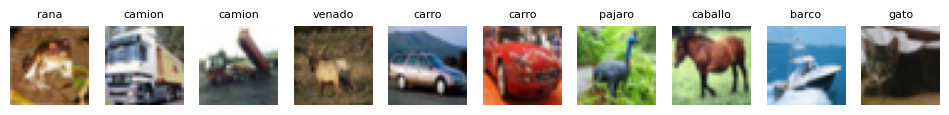

In [3]:
# bajamos CIFAR-10, son 60 mil imagenes chiquitas de 32x32
(cifar_train, y_train), (cifar_test, y_test) = cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()
# esto lo hacemos para normalizar, si no el modelo se demora mas
cifar_train = cifar_train.astype('float32') / 255.0
cifar_test = cifar_test.astype('float32') / 255.0
print(cifar_train.shape, cifar_test.shape)
nombres = ['avion','carro','pajaro','gato','venado','perro','rana','caballo','barco','camion']
plt.figure(figsize=(12,3))
for i in range(10):
    ax = plt.subplot(1,10,i+1)
    plt.imshow(cifar_train[i])
    plt.axis('off')
    ax.set_title(nombres[y_train[i]], fontsize=8)
plt.show()

## Armamos el autoencoder
Copiamos la idea del profe de la semana 5 con BatchNorm y Dropout, solo le metimos un Dense de 128 al final para poder hacer el PCA y el t-SNE que pide el examen. Sin ese Dense no se podia graficar en 2D.

In [4]:
# encoder, casi igual al del profe
inputs = Input(shape=(32, 32, 3))
x = Conv2D(32, 3, activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D()(x) # queda en 16x16
x = Dropout(0.5)(x) # esto es para que no se sobreajuste
skip = Conv2D(32, 3, padding='same')(x) # guardamos esto para sumarlo despues
x = LeakyReLU()(skip)
x = BatchNormalization()(x)
x = MaxPooling2D()(x) # queda en 8x8
x = Dropout(0.5)(x)
x = Conv2D(64, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(name='encoded_map')(x) # queda en 4x4x64
# aqui lo aplanamos para sacar el vector de 128, ese es el espacio latente
flat = tf.keras.layers.Flatten()(x)
latent = Dense(128, activation='relu', name='latent')(flat)
encoder = Model(inputs, latent, name='encoder')
encoder.summary()

I0000 00:00:1788655278.278936      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788655278.281633      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_map (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │       131,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,352 (626.38 KB)

 Trainable params: 160,096 (625.38 KB)

 Non-trainable params: 256 (1.00 KB)

In [5]:
# decoder, es el espejo del encoder
x = Dense(4*4*64, activation='relu')(latent)
x = tf.keras.layers.Reshape((4,4,64))(x)
x = Conv2DTranspose(64, 3, activation='relu', strides=(2,2), padding='same')(x) # sube a 8x8
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Conv2DTranspose(32, 3, activation='relu', strides=(2,2), padding='same')(x) # sube a 16x16
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Conv2DTranspose(32, 3, padding='same')(x)
# sumamos el skip que guardamos arriba, eso le copia al cuaderno del profe
x = tf.keras.layers.Add()([x, skip])
x = LeakyReLU()(x)
x = BatchNormalization()(x)
decoded = Conv2DTranspose(3, 3, activation='sigmoid', strides=(2,2), padding='same')(x)
autoencoder = Model(inputs, decoded)
# el profe usaba binary_crossentropy pero en el examen piden MSE, por eso usamos MSE
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │      9,248 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ leaky_re_lu[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 32)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8, 8, 32)  │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 64)  │     18,496 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoded_map         │ (None, 4, 4, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1024)      │          0 │ encoded_map[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent (Dense)      │ (None, 128)       │    131,200 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │    132,096 │ latent[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4, 4, 64)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 64)  │     36,928 │ reshape[0][0]     │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_transpose

 Total params: 358,467 (1.37 MB)

 Trainable params: 357,955 (1.37 MB)

 Non-trainable params: 512 (2.00 KB)

In [7]:
# entrenamos, en Kaggle con T4 se demora como 10 min
history = autoencoder.fit(cifar_train, cifar_train, epochs=25, batch_size=256, shuffle=True, validation_data=(cifar_test, cifar_test))

Epoch 1/25
  7/196 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0783

I0000 00:00:1788655308.758436     137 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


196/196 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - loss: 0.0114 - val_loss: 0.0292
Epoch 2/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0042 - val_loss: 0.0128
Epoch 3/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0036 - val_loss: 0.0038
Epoch 4/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0034 - val_loss: 0.0020
Epoch 5/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0032 - val_loss: 0.0018
Epoch 6/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0031 - val_loss: 0.0016
Epoch 7/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0030 - val_loss: 0.0015
Epoch 8/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0030 - val_loss: 0.0015
Epoch 9/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0029 - val_loss: 0.0015
Epoch 10/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0028 - val_loss: 0.0014
Epoch 11/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 12/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/st

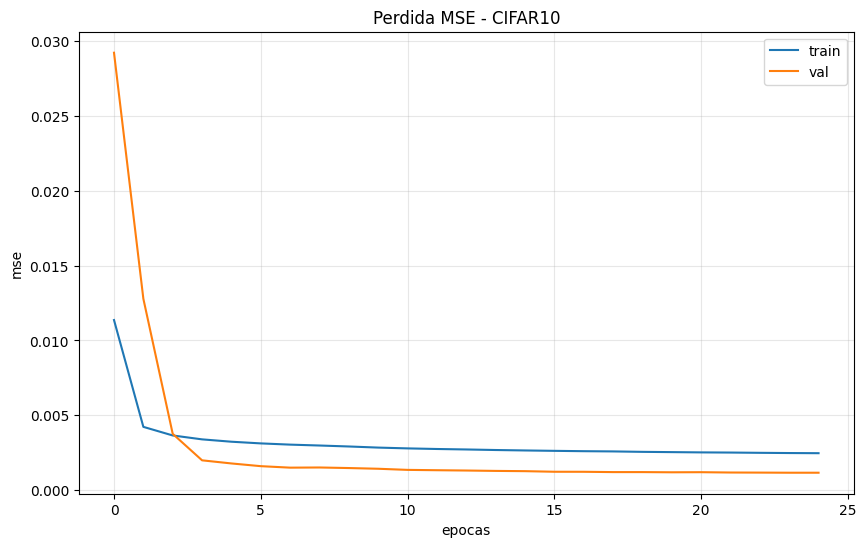

train final: 0.0024579439777880907
val final: 0.0011519878171384335


In [8]:
# curva de perdida, la guardamos para el informe
plt.figure(figsize=(10,6))
plt.plot(history.epoch, history.history['loss'], label='train')
plt.plot(history.epoch, history.history['val_loss'], label='val')
plt.title('Perdida MSE - CIFAR10')
plt.xlabel('epocas')
plt.ylabel('mse')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('/kaggle/working/Loss_curve_part1.pdf', format='pdf')
plt.show()
print('train final:', history.history['loss'][-1])
print('val final:', history.history['val_loss'][-1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


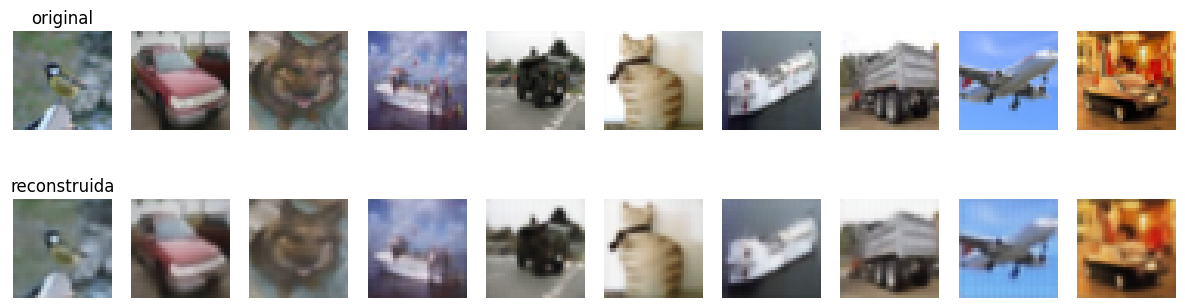

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 448ms/step


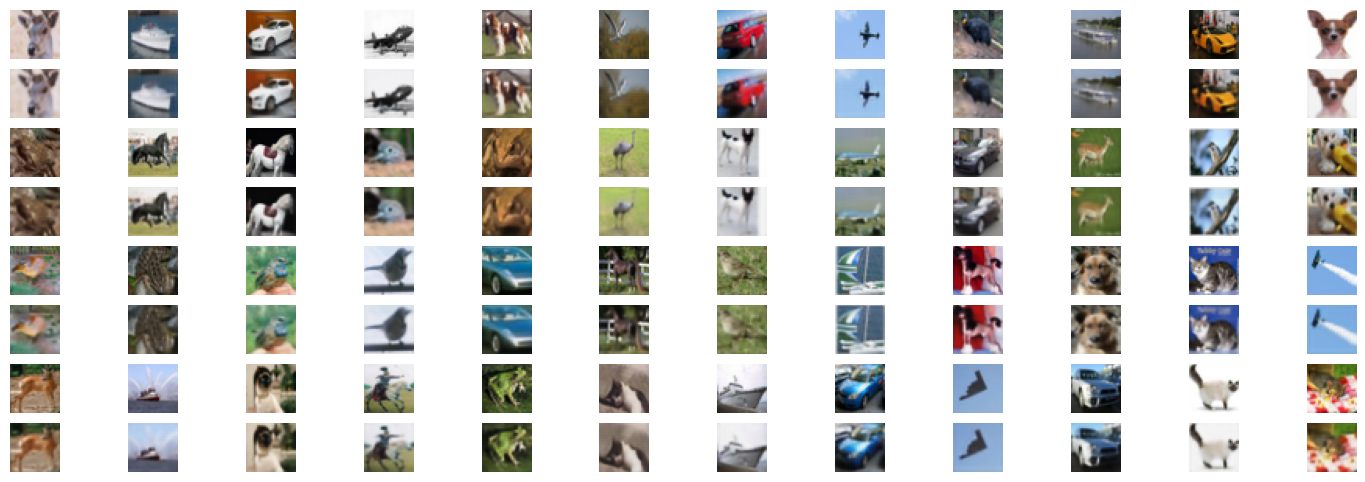

In [9]:
# comparamos originales con reconstruidas
idx = np.random.choice(len(cifar_test), 10, replace=False)
orig = cifar_test[idx]
recon = autoencoder.predict(orig)
plt.figure(figsize=(15,4))
for i in range(10):
    ax = plt.subplot(2, 10, i+1)
    plt.imshow(orig[i])
    plt.axis('off')
    if i == 0: ax.set_title('original')
    ax = plt.subplot(2, 10, i+1+10)
    plt.imshow(recon[i])
    plt.axis('off')
    if i == 0: ax.set_title('reconstruida')
plt.show()
# esta de 48 es la que vamos a meter al informe, igual a la del profe
r = np.random.randint(0, len(cifar_test)-48)
imgs48 = cifar_test[r:r+48]
rec48 = autoencoder.predict(imgs48)
f = plt.figure(figsize=(18,6))
for i in range(4):
    for j in range(12):
        k = i*12+j
        f.add_subplot(8, 12, (2*i*12)+(j+1))
        plt.imshow(imgs48[k]); plt.axis('off')
        f.add_subplot(8, 12, ((2*i+1)*12)+(j+1))
        plt.imshow(rec48[k]); plt.axis('off')
plt.savefig('/kaggle/working/test_results_part1.pdf', format='pdf')
plt.show()

## Espacio latente con PCA y t-SNE
Aca sacamos el vector de 128 de cada imagen y lo bajamos a 2D para poder graficarlo. El PCA es rapido y lineal, el t-SNE se demora mas pero separa mejor. Esto lo sacamos del cuaderno de la semana 1.

In [10]:
# sacamos el latente de 2000 imagenes, mas que eso el t-SNE se pone muy lento
sel = np.random.choice(len(cifar_test), 2000, replace=False)
x_vis = cifar_test[sel]
y_vis = y_test[sel]
lat = encoder.predict(x_vis, batch_size=256)
print(lat.shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
(2000, 128)


varianza con 2 comps: 0.4126


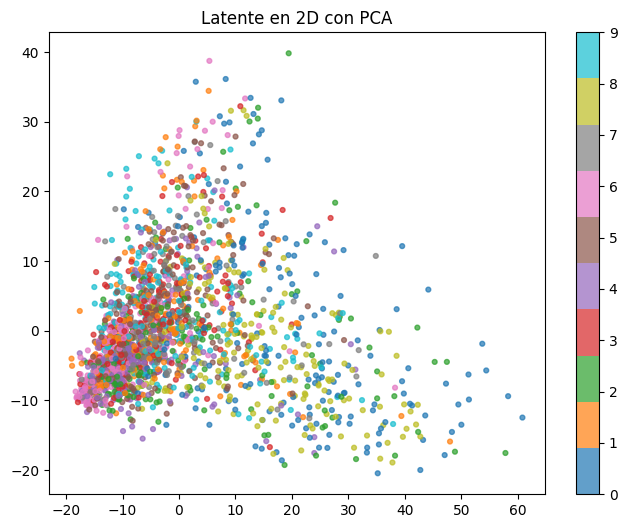

In [11]:
# PCA
pca = PCA(n_components=2, random_state=42)
z_pca = pca.fit_transform(lat)
print('varianza con 2 comps:', pca.explained_variance_ratio_.sum().round(4))
plt.figure(figsize=(8,6))
sc = plt.scatter(z_pca[:,0], z_pca[:,1], c=y_vis, cmap='tab10', s=12, alpha=0.7)
plt.colorbar(sc, ticks=range(10))
plt.title('Latente en 2D con PCA')
plt.show()

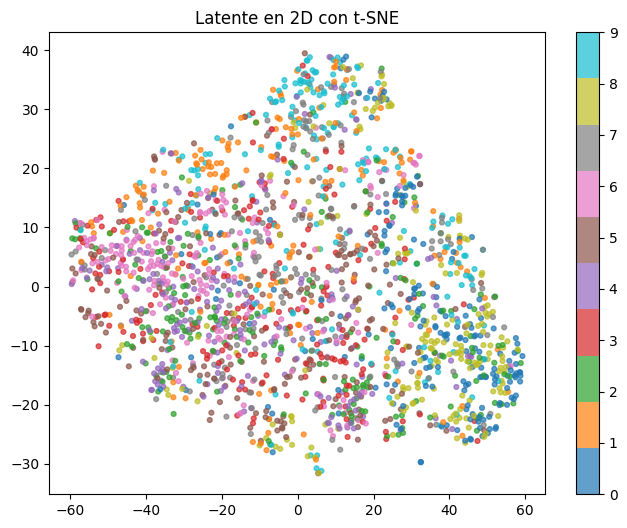

In [12]:
# t-SNE, este se demora unos minutos en Kaggle
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
z_tsne = tsne.fit_transform(lat)
plt.figure(figsize=(8,6))
sc = plt.scatter(z_tsne[:,0], z_tsne[:,1], c=y_vis, cmap='tab10', s=12, alpha=0.7)
plt.colorbar(sc, ticks=range(10))
plt.title('Latente en 2D con t-SNE')
plt.show()

## Lo que vimos
La reconstruccion sale un poco borrosa pero se reconoce, es normal porque comprimimos de 3072 a 128. El t-SNE separa mejor que el PCA. Hay clases que se mezclan como gato y perro o carro y camion, y tiene sentido porque se parecen.

Preguntas que nos pueden hacer: por que MSE y no BCE, que hace el skip, para que sirven el Dropout y el BatchNorm, y que pasa si el latente es muy pequeno.